In [4]:
from scipy.stats import uniform

In [5]:
uniform.rvs(scale = 10, size = 10)

array([2.06799734, 4.23763922, 0.65217757, 5.03804466, 6.32682929,
       4.30665084, 8.49671739, 8.35137963, 0.18359394, 1.11456252])

In [6]:
def myRandomGenerator(x, p, size=1):
    lista = []
    for _ in range(size):
        Y = uniform.rvs(loc=0, scale=1)
        sum_prob = 0
        for i in range(len(p)):
            sum_prob += p[i]
            if Y < sum_prob:
                lista.append(x[i])
                break
    return lista

In [8]:
myRandomGenerator(['a','b','c'], [1/6, 1/3, 1/2], 10)

['b', 'c', 'c', 'b', 'c', 'c', 'c', 'c', 'a', 'c']

In [9]:
from random import randrange
from matplotlib.pyplot import bar, hist, grid, show, legend

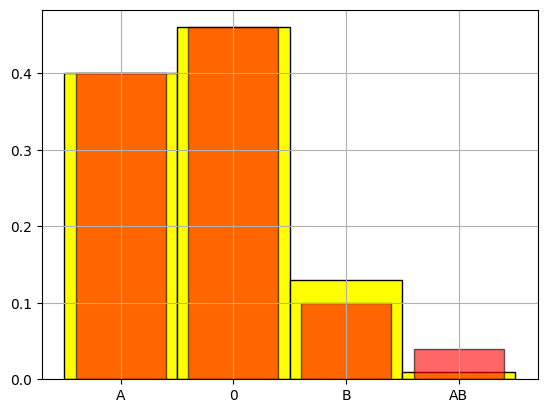

In [30]:
x_vals = ['0','A','B','AB']
p_vals = [0.46,0.4,0.1,0.04]

samples = myRandomGenerator(x_vals, p_vals, size=100)
bin_edges = [ -0.5, 0.5, 1.5, 2.5,3.5 ]

hist(samples, bins=bin_edges, density=True, edgecolor='black', label="Histogram", color = 'yellow')
distribution = {'0':0.46,'A':0.4,'B':0.1,'AB':0.04}
bar(distribution.keys(), distribution.values(), width = 0.8, color = 'red', edgecolor = 'black', alpha = 0.6)

grid()
show()

In [66]:
from math import log,exp

def myRandomGenerator2(alpha, size=1):
    lista = []
    for _ in range(size):
        Y = uniform.rvs()
        X = -1/alpha * log(1 - Y)
        lista.append(X)
    return lista

In [67]:
print(myRandomGenerator2(1, 10))

[0.4620748385211885, 1.3973844581458987, 2.423032666350999, 1.6438811647431866, 0.2433224949976939, 0.8031316168877133, 1.8948144550473998, 3.3370801758993354, 0.9024747842643697, 0.7188721362113379]


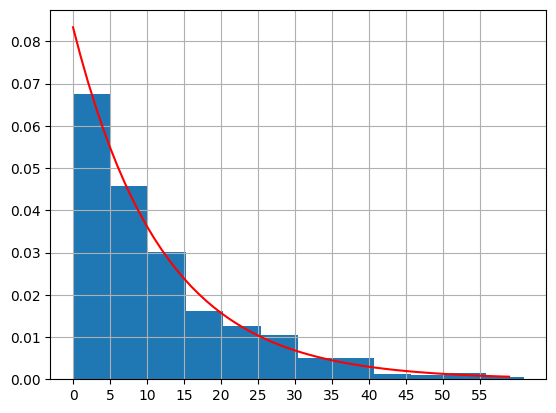

In [68]:
from matplotlib.pyplot import show, hist, grid, legend, xticks, plot
from scipy.stats import expon

alpha = 1 / 12
N=1000
data = myRandomGenerator2(alpha, N)
hist(data, bins=12, density = True, range=(0,61))
x = range(60)
plot(x,expon.pdf(x,loc=0,scale=1/alpha),'r-')
xticks(range(0,60,5))
grid()
show()


In [69]:
import numpy as np
count_fav=sum(1 for x in data if x >= 5) 
p_simulat=count_fav/len(data)
print(p_simulat)

0.66


In [70]:
p_teoretic = 1 - expon.cdf(5, scale=1/alpha)
print(p_teoretic)

0.6592406302004438
